In [37]:
# Imporing rdkit

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

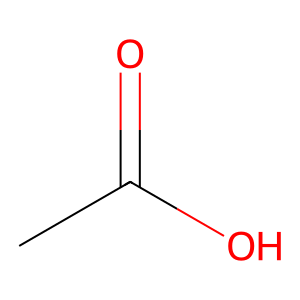

In [16]:
# creating a molecule

smiles = "CC(=O)O"  # Ethanol
mol = Chem.MolFromSmiles(smiles)
# Visualizing the molecule 
Draw.MolToImage(mol)

In [21]:
# Calculate the descriptors for the molecule, execute line by line to get the output 
# Molecular weight
Descriptors.MolWt(mol)
# No of Hydrogen bond donors
Descriptors.NumHDonors(mol)
# No of Hydrogen bond acceptors
Descriptors.NumHAcceptors(mol)

1

In [43]:
# create molecular fingerprints
from rdkit.Chem import AllChem

fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
fp

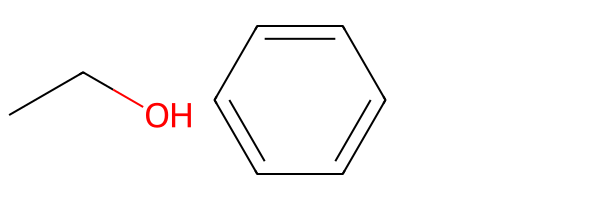

In [22]:
# create multiple molecules
mols = [Chem.MolFromSmiles(s) for s in ["CCO", "c1ccccc1"]]
Draw.MolsToGridImage(mols, molsPerRow=3)

In [41]:
# Basic Validaton
# Molecule standardization
# Removing salts and ions 
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

# Example with salt
smiles = "CCO.Cl"

mol = Chem.MolFromSmiles(smiles)

cleaner = rdMolStandardize.LargestFragmentChooser()
mol_clean = cleaner.choose(mol)

print("Original:", smiles)
print("Cleaned :", Chem.MolToSmiles(mol_clean))

Original: CCO.Cl
Cleaned : CCO


[19:48:15] Running LargestFragmentChooser
[19:48:15] Fragment: CCO
[19:48:15] New largest fragment: CCO (9)
[19:48:15] Fragment: Cl


In [46]:
# Charge Neutralization 
smiles = "[NH4+]"
mol = Chem.MolFromSmiles(smiles)

Chem.MolToSmiles(mol)
uncharger = rdMolStandardize.Uncharger()
mol_clean = uncharger.uncharge(mol)

Chem.MolToSmiles(mol_clean)

[20:06:32] Running Uncharger
[20:06:32] Removed positive charge.


'N'

In [47]:
 # Functional group normalization
smiles = "C[N+](=O)[O-]"
mol = Chem.MolFromSmiles(smiles)
normalizer = rdMolStandardize.Normalizer()
mol_clean = normalizer.normalize(mol)

Chem.MolToSmiles(mol_clean)

[21:19:16] Initializing Normalizer
[21:19:16] Running Normalizer


'C[N+](=O)[O-]'

In [49]:
# Tautomer canonicalization
smiles1 = "C1=CC=CN=C1"   # pyridine-like
smiles2 = "C1=NC=CC=C1"

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)
te = rdMolStandardize.TautomerEnumerator()

mol1_clean = te.Canonicalize(mol1)
mol2_clean = te.Canonicalize(mol2)

Chem.MolToSmiles(mol1_clean), Chem.MolToSmiles(mol2_clean)

('c1ccncc1', 'c1ccncc1')

In [50]:
# duplicate removal from canonical smiles
smiles1 = "CCO"
smiles2 = "OCC"

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)
Chem.MolToSmiles(mol1, canonical=True)
Chem.MolToSmiles(mol2, canonical=True)

'CCO'

In [52]:
# Sanitization
smiles = "C=[C]=C"   # can cause valence issues
mol = Chem.MolFromSmiles(smiles, sanitize=False)
Chem.SanitizeMol(mol)

rdkit.Chem.rdmolops.SanitizeFlags.SANITIZE_NONE

In [53]:
# Molecular Standardization Pipeline with RDKit
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

def clean_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Remove salts
    mol = rdMolStandardize.LargestFragmentChooser().choose(mol)

    # Neutralize
    mol = rdMolStandardize.Uncharger().uncharge(mol)

    # Normalize
    mol = rdMolStandardize.Normalizer().normalize(mol)

    return Chem.MolToSmiles(mol)

print(clean_molecule("C[NH+](C)(C).[Cl-]"))

CN(C)C


[21:31:44] Running LargestFragmentChooser
[21:31:44] Fragment: C[NH+](C)C
[21:31:44] New largest fragment: C[NH+](C)C (14)
[21:31:44] Fragment: [Cl-]
[21:31:44] Running Uncharger
[21:31:44] Initializing Normalizer
[21:31:44] Running Normalizer


In [2]:
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize

# -----------------------------
# Cleaning function
# -----------------------------
def clean_molecule(mol):
    if mol is None:
        return None
    try:
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = rdMolStandardize.Normalizer().normalize(mol)
        Chem.SanitizeMol(mol)
        return mol
    except:
        return None

# -----------------------------
# Load molecules
# -----------------------------
def load_molecules(input_path):
    ext = os.path.splitext(input_path)[1].lower()
    mols = []

    if ext == ".smi" or ext == ".smiles" or ext == ".txt":
        with open(input_path) as f:
            for line in f:
                smi = line.strip().split()[0]
                mol = Chem.MolFromSmiles(smi)
                if mol:
                    mols.append(mol)

    elif ext == ".sdf":
        suppl = Chem.SDMolSupplier(input_path)
        mols = [m for m in suppl if m is not None]

    elif ext == ".mol2":
        mol = Chem.MolFromMol2File(input_path, sanitize=False)
        if mol:
            mols = [mol]

    else:
        raise ValueError("Unsupported file format")

    return mols

# -----------------------------
# Save molecules
# -----------------------------
def save_molecules(mols, output_path):
    ext = os.path.splitext(output_path)[1].lower()

    if ext == ".smi":
        with open(output_path, "w") as f:
            for mol in mols:
                smi = Chem.MolToSmiles(mol)
                f.write(smi + "\n")

    elif ext == ".sdf":
        writer = Chem.SDWriter(output_path)
        for mol in mols:
            writer.write(mol)
        writer.close()

    elif ext == ".mol2":
        for i, mol in enumerate(mols):
            out = output_path.replace(".mol2", f"_{i}.mol2")
            Chem.MolToMol2File(mol, out)

    else:
        raise ValueError("Unsupported output format")

# -----------------------------
# Main execution
# -----------------------------
input_path = input("Enter input file path: ")
output_path = input("Enter output file path: ")

molecules = load_molecules(input_path)

cleaned = []
for mol in molecules:
    cmol = clean_molecule(mol)
    if cmol:
        cleaned.append(cmol)

save_molecules(cleaned, output_path)

print(f"Done! {len(cleaned)} molecules saved.")

Enter input file path: C:/Users/ravit/Desktop/TYK2/TESTTYK2.sdf
Enter output file path: C:/Users/ravit/Desktop/TYK2/TESTTYK2_cur1.sdf


[12:01:21] Running LargestFragmentChooser
[12:01:21] Fragment: CC(C)(C)NS(=O)(=O)c1ccc(-c2cc3c(N)ncc(C(=O)NCCCN4CCOCC4)c3s2)cc1
[12:01:21] New largest fragment: CC(C)(C)NS(=O)(=O)c1ccc(-c2cc3c(N)ncc(C(=O)NCCCN4CCOCC4)c3s2)cc1 (69)
[12:01:21] Running Uncharger
[12:01:21] Initializing Normalizer
[12:01:21] Running Normalizer
[12:01:21] Running LargestFragmentChooser
[12:01:21] Fragment: O=C(Nc1ccnc(NC(=O)C2CC2)c1)c1c(Cl)cc(CO)cc1Cl
[12:01:21] New largest fragment: O=C(Nc1ccnc(NC(=O)C2CC2)c1)c1c(Cl)cc(CO)cc1Cl (40)
[12:01:21] Running Uncharger
[12:01:21] Initializing Normalizer
[12:01:21] Running Normalizer
[12:01:21] Running LargestFragmentChooser
[12:01:21] Fragment: CS(=O)(=O)Nc1cc(Cl)c(C(=O)Nc2ccnc(NC(=O)C3CC3)c2)c(Cl)c1
[12:01:21] New largest fragment: CS(=O)(=O)Nc1cc(Cl)c(C(=O)Nc2ccnc(NC(=O)C3CC3)c2)c(Cl)c1 (44)
[12:01:21] Running Uncharger
[12:01:21] Initializing Normalizer
[12:01:21] Running Normalizer
[12:01:21] Running LargestFragmentChooser
[12:01:21] Fragment: C[C@@H]1C[C@@H]1

Done! 1842 molecules saved.


In [1]:
import os
import csv
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from tqdm import tqdm   # progress bar

# -----------------------------
# STANDARDIZATION FUNCTION
# -----------------------------
def standardize_molecule(mol):
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Normalizer().normalize(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)

        te = rdMolStandardize.TautomerEnumerator()
        mol = te.Canonicalize(mol)

        Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
        mol = Chem.RemoveHs(mol)
        Chem.SanitizeMol(mol)

        return mol
    except:
        return None

# -----------------------------
# LOAD MOLECULES
# -----------------------------
def load_molecules(input_path):
    ext = os.path.splitext(input_path)[1].lower()
    mols = []

    if ext in [".smi", ".smiles", ".txt"]:
        with open(input_path) as f:
            for line in f:
                if line.strip():
                    smi = line.strip().split()[0]
                    mols.append((smi, Chem.MolFromSmiles(smi)))

    elif ext == ".csv":
        with open(input_path) as f:
            reader = csv.DictReader(f)
            for row in reader:
                smi = row["smiles"]
                mols.append((smi, Chem.MolFromSmiles(smi)))

    elif ext == ".sdf":
        suppl = Chem.SDMolSupplier(input_path)
        for mol in suppl:
            smi = Chem.MolToSmiles(mol) if mol else None
            mols.append((smi, mol))

    elif ext == ".mol2":
        mol = Chem.MolFromMol2File(input_path, sanitize=False)
        mols = [(None, mol)]

    else:
        raise ValueError("Unsupported input format")

    return mols

# -----------------------------
# SAVE MOLECULES
# -----------------------------
def save_molecules(mols, output_path):
    ext = os.path.splitext(output_path)[1].lower()

    if ext in [".smi", ".smiles", ".txt"]:
        with open(output_path, "w") as f:
            for mol in mols:
                f.write(Chem.MolToSmiles(mol) + "\n")

    elif ext == ".sdf":
        writer = Chem.SDWriter(output_path)
        for mol in mols:
            writer.write(mol)
        writer.close()

    elif ext == ".mol2":
        base = output_path.replace(".mol2", "")
        for i, mol in enumerate(mols):
            Chem.MolToMol2File(mol, f"{base}_{i}.mol2")

# -----------------------------
# MAIN
# -----------------------------
def main():
    input_path = input("Enter input file path: ").strip()
    output_path = input("Enter output file path: ").strip()

    data = load_molecules(input_path)
    total = len(data)

    cleaned = []
    failed = []
    unique_smiles = set()

    print(f"\nProcessing {total} molecules...\n")

    # Progress bar with live stats
    with tqdm(total=total, desc="Standardizing", unit="mol") as pbar:
        for i, (original_smi, mol) in enumerate(data):

            cmol = standardize_molecule(mol)

            if cmol:
                smi = Chem.MolToSmiles(cmol, canonical=True)

                if smi not in unique_smiles:
                    unique_smiles.add(smi)
                    cleaned.append(cmol)
            else:
                failed.append(original_smi)

            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({
                "cleaned": len(cleaned),
                "failed": len(failed)
            })

    # Save results
    save_molecules(cleaned, output_path)

    with open("failed.log", "w") as f:
        for smi in failed:
            f.write(str(smi) + "\n")

    print("\n✅ Finished!")
    print(f"✔️ Total processed : {total}")
    print(f"✔️ Cleaned unique : {len(cleaned)}")
    print(f"❌ Failed         : {len(failed)}")

# Run
if __name__ == "__main__":
    main()

Enter input file path: C:/Users/ravit/Desktop/TYK2/TESTTYK2.sdf
Enter output file path: C:/Users/ravit/Desktop/TYK2/TESTTYK2_curated.sdf

Processing 1842 molecules...



Standardizing:   0%|                                                                         | 0/1842 [00:00<?, ?mol/s][11:48:53] Running LargestFragmentChooser
[11:48:53] Fragment: CC(C)(C)NS(=O)(=O)c1ccc(-c2cc3c(N)ncc(C(=O)NCCCN4CCOCC4)c3s2)cc1
[11:48:53] New largest fragment: CC(C)(C)NS(=O)(=O)c1ccc(-c2cc3c(N)ncc(C(=O)NCCCN4CCOCC4)c3s2)cc1 (69)
[11:48:53] Initializing Normalizer
[11:48:53] Running Normalizer
[11:48:53] Running Uncharger
Standardizing:   0%|                                            | 1/1842 [00:00<01:11, 25.66mol/s, cleaned=1, failed=0][11:48:53] Running LargestFragmentChooser
[11:48:53] Fragment: O=C(Nc1ccnc(NC(=O)C2CC2)c1)c1c(Cl)cc(CO)cc1Cl
[11:48:53] New largest fragment: O=C(Nc1ccnc(NC(=O)C2CC2)c1)c1c(Cl)cc(CO)cc1Cl (40)
[11:48:53] Initializing Normalizer
[11:48:53] Running Normalizer
[11:48:53] Running Uncharger
Standardizing:   0%|                                            | 2/1842 [00:00<01:12, 25.42mol/s, cleaned=2, failed=0][11:48:53] Running LargestFragm


✅ Finished!
✔️ Total processed : 1842
✔️ Cleaned unique : 1516
❌ Failed         : 9


In [3]:
# converion of formats

In [7]:
from rdkit import Chem
import pandas as pd

sdf_file = "C:/Users/ravit/Desktop/TYK2/TESTTYK2.sdf"
supplier = Chem.SDMolSupplier(sdf_file)

data = []

for i, mol in enumerate(supplier):
    if mol is None:
        continue
    
    smiles = Chem.MolToSmiles(mol)
    
    # Optional: get molecule name or properties
    name = mol.GetProp("_Name") if mol.HasProp("_Name") else f"mol_{i}"
    
    data.append({
        "name": name,
        "smiles": smiles
    })

df = pd.DataFrame(data)
df.to_csv("C:/Users/ravit/Desktop/TYK2/TESTTYK2_curated.csv", index=False)

print("Converted SDF → SMILES. Total molecules:", len(df))

Converted SDF → SMILES. Total molecules: 1842


In [8]:
from rdkit import Chem
import pandas as pd

df = pd.read_csv("C:/Users/ravit/Desktop/TYK2/TESTTYK2_curated.csv")

writer = Chem.SDWriter("C:/Users/ravit/Desktop/TYK2/TESTTYK2_curated12.sdf")

for i, row in df.iterrows():
    smiles = row["smiles"]
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        continue
    
    # Add name if available
    if "name" in df.columns:
        mol.SetProp("_Name", str(row["name"]))
    else:
        mol.SetProp("_Name", f"mol_{i}")
    
    writer.write(mol)

writer.close()

print("Converted SMILES → SDF")

Converted SMILES → SDF
